# 線性代數

## 向量(Vector)

In [1]:
# 載入套件
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

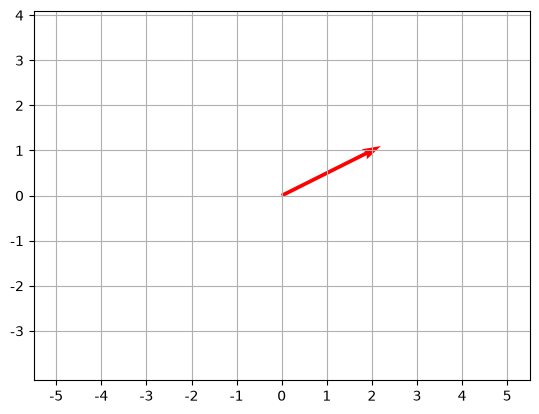

In [2]:
# 向量(Vector)
v = np.array([2, 1])

# 作圖
plt.axis('equal')
plt.grid()

# 原點
origin = [0], [0]

# 畫有箭頭的線
plt.quiver(*origin, *v, scale=10, color='r')

plt.xticks(np.arange(-0.05, 0.06, 0.01), labels=[str(i) for i in np.arange(-5, 6, 1)])
plt.yticks(np.arange(-3, 5, 1) / 100, labels=[str(i) for i in np.arange(-3, 5, 1)])
plt.show()

## 向量長度(magnitude)計算

## 📏 向量長度（範數 Norm）的計算公式

向量的長度代表該向量從座標原點 $(0,0,\dots,0)$ 到其終點的**幾何距離**。在數學與機器學習中，最常使用的向量長度計算公式是 **$L_2$ 範數（Euclidean Norm）**。

---

### 1. 二維與三維空間（幾何直覺）

在低維度空間中，向量長度的公式本質上就是**畢氏定理（勾股定理）**的延伸。

*   **二維空間向量** $\mathbf{v} = [x, y]^T$ 的長度：
    $$\|\mathbf{v}\| = \sqrt{x^2 + y^2}$$

*   **三維空間向量** $\mathbf{v} = [x, y, z]^T$ 的長度：
    $$\|\mathbf{v}\| = \sqrt{x^2 + y^2 + z^2}$$

---

### 2. $n$ 維空間（機器學習與資料科學常用）

在處理高維度特徵（例如內嵌向量 Embedding 或資料點）時，假設有一個 $n$ 維向量 $\mathbf{v} = [v_1, v_2, v_3, \dots, v_n]^T$，其長度的計算公式如下：

$$\boxed{\|\mathbf{v}\|_2 = \sqrt{\sum_{i=1}^{n} v_i^2} = \sqrt{v_1^2 + v_2^2 + v_3^2 + \dots + v_n^2}}$$

#### 💡 矩陣運算表示法
在進行高效的線性代數運算時，向量的長度平方等於**向量自身的轉置與自身相乘（內積/點積）**。因此公式也可以寫成：
$$\|\mathbf{v}\|_2 = \sqrt{\mathbf{v}^T \mathbf{v}}$$

> 📌 **符號說明：** 
> 雙豎線 $\|\mathbf{v}\|$ 代表向量的範數。右下角的數字 $2$ 代表這是 $L_2$ 範數。如果平時沒有特別標註數字，預設指的就是 $L_2$ 歐氏長度。

---

### 3. 其他常見的向量長度定義（補充）

除了最常用的 $L_2$ 範數，在某些特定的場景（如 L1 正規化、Lasso 迴歸）也會使用以下定義：

*   **$L_1$ 範數（曼哈頓距離 / Manhattan Norm）：** 所有元素絕對值的總和（常用於稀疏矩陣）。
    $$\|\mathbf{v}\|_1 = \sum_{i=1}^{n} |v_i|$$
*   **$L_\infty$ 範數（切比雪夫距離 / Max Norm）：** 所有元素中絕對值最大的那個數。
    $$\|\mathbf{v}\|_\infty = \max_{i} (|v_i|)$$


In [3]:
# 向量(Vector)
v = np.array([2, 1])

# 向量長度(magnitude)計算
(v[0] ** 2 + v[1] ** 2) ** (1 / 2)

np.float64(2.23606797749979)

In [4]:
# 使用 np.linalg.norm() 計算向量長度(magnitude)
magnitude = np.linalg.norm(v)
print(magnitude)

2.23606797749979


In [5]:
# 使用 PyTorch
torch.linalg.norm(torch.FloatTensor(v))

tensor(2.2361)

## 計算方向(direction)

In [6]:
# 向量(Vector)
v = np.array([2, 1])

vTan = v[1] / v[0]
print('tan(θ) = 1/2')

theta = math.atan(vTan)
print('弳度(radian) =', round(theta, 4))
print('角度(degree) =', round(theta * 180 / math.pi, 2))

# 也可以使用 math.degrees() 轉換角度
print('角度(degree) =', round(math.degrees(theta), 2))

tan(θ) = 1/2
弳度(radian) = 0.4636
角度(degree) = 26.57
角度(degree) = 26.57


## 向量加法：加減一個常數，長度、方向均改變

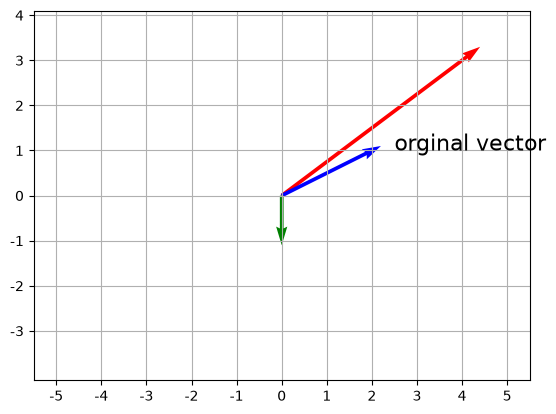

In [7]:
# 向量(Vector) + 2
v = np.array([2, 1])
v1 = np.array([2, 1]) + 2
v2 = np.array([2, 1]) - 2

# 原點
origin = [0], [0]

# 畫有箭頭的線
plt.quiver(*origin, *v1, scale=10, color='r')
plt.quiver(*origin, *v, scale=10, color='b')
plt.quiver(*origin, *v2, scale=10, color='g')

plt.annotate('orginal vector', (0.025, 0.01), xycoords='data', fontsize=16)

# 作圖
plt.axis('equal')
plt.grid()

plt.xticks(np.arange(-0.05, 0.06, 0.01), labels=[str(i) for i in np.arange(-5, 6, 1)])
plt.yticks(np.arange(-3, 5, 1) / 100, labels=[str(i) for i in np.arange(-3, 5, 1)])
plt.show()

## 向量乘除法：乘除一個常數，長度改變、方向不改變

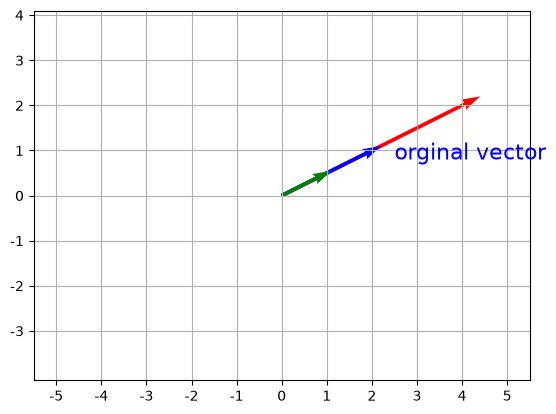

In [8]:
# 向量(Vector) * 2
v = np.array([2, 1])
v1 = np.array([2, 1]) * 2
v2 = np.array([2, 1]) / 2

# 原點
origin = [0], [0]

# 畫有箭頭的線
plt.quiver(*origin, *v1, scale=10, color='r')
plt.quiver(*origin, *v, scale=10, color='b')
plt.quiver(*origin, *v2, scale=10, color='g')

plt.annotate('orginal vector', (0.025, 0.008), xycoords='data', color='b', fontsize=16)

# 作圖
plt.axis('equal')
plt.grid()

plt.xticks(np.arange(-0.05, 0.06, 0.01), labels=[str(i) for i in np.arange(-5, 6, 1)])
plt.yticks(np.arange(-3, 5, 1) / 100, labels=[str(i) for i in np.arange(-3, 5, 1)])
plt.show()

## 向量加減乘除另一個向量：兩個向量的相同位置的元素作加減乘除。

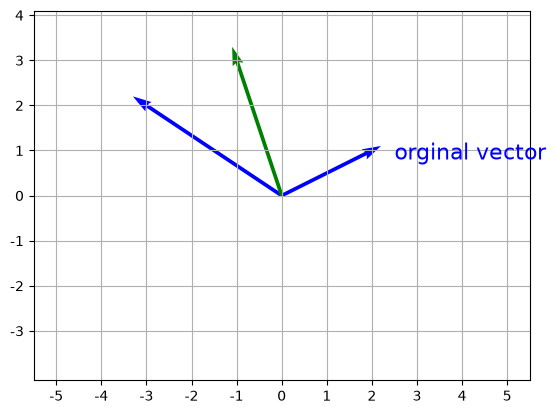

In [9]:
# 向量1(Vector) + 向量2(Vector)
v = np.array([2, 1])
s = np.array([-3, 2])
v2 = v + s

# 原點
origin = [0], [0]

# 畫有箭頭的線
plt.quiver(*origin, *v, scale=10, color='b')
plt.quiver(*origin, *s, scale=10, color='b')
plt.quiver(*origin, *v2, scale=10, color='g')

plt.annotate('orginal vector', (0.025, 0.008), xycoords='data', color='b', fontsize=16)

# 作圖
plt.axis('equal')
plt.grid()

plt.xticks(np.arange(-0.05, 0.06, 0.01), labels=[str(i) for i in np.arange(-5, 6, 1)])
plt.yticks(np.arange(-3, 5, 1) / 100, labels=[str(i) for i in np.arange(-3, 5, 1)])
plt.show()

## 『內積』(Inner Product)或稱『點積乘法』(Dot Product)

## 🤝 向量內積（Dot Product / Scalar Product）

向量內積的核心精神在於：**衡量兩個向量在空間中的「同步程度」或「投影關係」**。它的最終計算結果不是向量，而是一個**純量（Scalar）**。

---

### 1. 雙重定義與公式

向量內積有兩種等價的計算方式，分別從**代數（坐標）**與**幾何（空間角度）**出發：

#### 🧮 A. 代數定義（坐標乘積和）
假設有兩個 $n$ 維向量 $\mathbf{a} = [a_1, a_2, \dots, a_n]^T$ 與 $\mathbf{b} = [b_1, b_2, \dots, b_n]^T$，內積就是將對應位置的元素相乘後全部加總：

$$\boxed{\mathbf{a} \cdot \mathbf{b} = \mathbf{a}^T \mathbf{b} = \sum_{i=1}^{n} a_i b_i = a_1 b_1 + a_2 b_2 + \dots + a_n b_n}$$

---

#### 📐 B. 幾何定義（投影與夾角）
內積也可以透過兩個向量的**長度（$L_2$ 範數）**與它們之間的**夾角 $\theta$** 來計算：

$$\boxed{\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\|_2 \|\mathbf{b}\|_2 \cos(\theta)}$$

*   $\|\mathbf{a}\|_2$ 和 $\|\mathbf{b}\|_2$ 分別代表兩向量的幾何長度。
*   $\theta$ 為兩向量在空間中的夾角（$0^\circ \le \theta \le 180^\circ$）。

> 💡 **這兩種定義為什麼等價？** 
> 在幾何上，$\|\mathbf{a}\|_2 \cos(\theta)$ 代表將向量 $\mathbf{a}$ 垂直**投影**到向量 $\mathbf{b}$ 上的長度。因此，內積的本質就是：**「一個向量在另一個向量上的投影長度」乘以「另一個向量的自身長度」**。

---

### 2. 內積正負號的物理與幾何意義

透過幾何定義中的 $\cos(\theta)$，我們可以單看內積的**正負號**來秒懂兩個向量的相對方向：

*   **$\mathbf{a} \cdot \mathbf{b} > 0$ （正值）：** 夾角為銳角（$0^\circ \le \theta < 90^\circ$）。兩向量方向相近，具有**正相關**。
*   **$\mathbf{a} \cdot \mathbf{b} = 0$ （零）：** 夾角恰為直角（$\theta = 90^\circ$）。在線性代數中稱為 **正交（Orthogonal）**。代表兩向量完全獨立，毫無關聯。
*   **$\mathbf{a} \cdot \mathbf{b} < 0$ （負值）：** 夾角為鈍角（$90^\circ < \theta \le 180^\circ$）。兩向量方向相反，具有**負相關**。

---

### 3. 機器學習中的殺手級應用：餘弦相似度 (Cosine Similarity)

利用上述兩個公式的等價性，我們可以將幾何公式移項，直接計算出任意高維向量（如：AI 文本內嵌向量 Embedding）之間的夾角餘弦值，用來評估**兩資料點的相似度**：

$$\cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|_2 \|\mathbf{b}\|_2} = \frac{\sum a_i b_i}{\sqrt{\sum a_i^2} \sqrt{\sum b_i^2}}$$

*   若 $\cos(\theta) = 1$：方向完全相同，內容極度相似。
*   若 $\cos(\theta) = 0$：方向完全垂直，內容毫無關聯。
*   若 $\cos(\theta) = -1$：方向完全相反，內容互斥。


In [10]:
# 向量(Vector)
v = np.array([2, 1])
s = np.array([-3, 2])

# 內積
d = v @ s  # 或 np.dot(v, s)、v.dot(s)

print(d)

-4


## 計算夾角 θ

In [11]:
# 向量(Vector)
v = np.array([2, 1])
s = np.array([-3, 2])

# 計算長度(magnitudes)
vMag = np.linalg.norm(v)
sMag = np.linalg.norm(s)

# 計算 cosine(θ)
cos = (v @ s) / (vMag * sMag)

# 計算 θ
theta = math.degrees(math.acos(cos))
print(theta)

119.74488129694222


# 矩陣(Matrix)

## 矩陣加法

In [12]:
# 矩陣
A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array([[6, 5, 4], [3, 2, 1]])

# 加法
print(A + B)

[[7 7 7]
 [7 7 7]]


## 矩陣減法

In [13]:
# 減法
print(A - B)

[[-5 -3 -1]
 [ 1  3  5]]


## 矩陣乘法

## 🧮 矩陣乘法（Matrix Multiplication）

矩陣乘法並不是將對應位置的元素簡單相乘（那是 Element-wise 乘法），而是透過左矩陣的**列（Row）**與右矩陣的**行（Column）**進行**內積**運算。

---

### 1. 核心規則：維度匹配（Dimension Matching）

兩個矩陣 $\mathbf{A}$ 和 $\mathbf{B}$ 想要進行矩陣乘法 $\mathbf{A} \times \mathbf{B}$，必須滿足一個鐵律：
> **左矩陣的「行數（欄數）」必須等於右矩陣的「列數」！**

*   假設矩陣 $\mathbf{A}$ 的維度是 $\color{blue}{m} \times \color{red}{n}$
*   假設矩陣 $\mathbf{B}$ 的維度是 $\color{red}{n} \times \color{green}{p}$
*   相乘後得到的全新矩陣 $\mathbf{C}$，其維度將會是 $\color{blue}{m} \times \color{green}{p}$

$$\mathbf{A}_{(\color{blue}{m} \times \color{red}{n})} \times \mathbf{B}_{(\color{red}{n} \times \color{green}{p})} = \mathbf{C}_{(\color{blue}{m} \times \color{green}{p})}$$

---

### 2. 數學定義與計算方式

設 $\mathbf{A}$ 為 $m \times n$ 矩陣，$\mathbf{B}$ 為 $n \times p$ 矩陣，則相乘後的矩陣 $\mathbf{C} = \mathbf{A}\mathbf{B}$ 中，位於第 $i$ 列、第 $j$ 行的元素 $c_{ij}$ 的計算公式為：

$$\boxed{c_{ij} = \sum_{k=1}^{n} a_{ik} b_{kj} = a_{i1}b_{1j} + a_{i2}b_{2j} + \dots + a_{in}b_{nj}}$$

#### 📐 視覺化拆解圖
要計算 $\mathbf{C}$ 矩陣左上角第一個元素 $c_{11}$：
1. 取出 $\mathbf{A}$ 矩陣的**第一列（Row 1）**向量。
2. 取出 $\mathbf{B}$ 矩陣的**第一行（Column 1）**向量。
3. 將這兩個向量做**內積（對應相乘後加總）**，得到的純量就是 $c_{11}$。

$$\begin{bmatrix} \mathbf{a_{11}} & \mathbf{a_{12}} \\ a_{21} & a_{22} \end{bmatrix} \times \begin{bmatrix} \mathbf{b_{11}} & b_{12} \\ \mathbf{b_{21}} & b_{22} \end{bmatrix} = \begin{bmatrix} \mathbf{(a_{11}b_{11} + a_{12}b_{21})} & c_{12} \\ c_{21} & c_{22} \end{bmatrix}$$

---

### 3. 矩陣乘法的重要數學性質

矩陣乘法的運算規則與傳統代數數字乘法有很大的不同，這點在公式推導時極為關鍵：

*   **🚫 沒有交換律（Non-commutative）：** $\mathbf{A}\mathbf{B} \neq \mathbf{B}\mathbf{A}$（順序一旦對調，維度可能不匹配，就算維度匹配，計算出的數值也完全不同）。
*   **✅ 結合律（Associative）：** $(\mathbf{A}\mathbf{B})\mathbf{C} = \mathbf{A}(\mathbf{B}\mathbf{C})$
*   **✅ 分配律（Distributive）：** $\mathbf{A}(\mathbf{B} + \mathbf{C}) = \mathbf{A}\mathbf{B} + \mathbf{A}\mathbf{C}$
*   **🔄 轉置矩陣穿鞋脫襪原理（Transpose of Product）：** 
    $$(\mathbf{A}\mathbf{B})^T = \mathbf{B}^T \mathbf{A}^T$$
    > *註：相乘後再轉置，等同於各自轉置後「顛倒順序」相乘。這個性質在機器學習（如前面推導 MSE 損失函數）時天天都會用到！*

---

### 4. 機器學習中的直觀理解：空間變換

在 AI 與線性代數中，我們常把 $\mathbf{x}$ 看作一個輸入向量，而矩陣 $\mathbf{W}$ 看作一個**空間變換算子（系統/網路權重）**。
矩陣乘法 $\mathbf{W}\mathbf{x}$ 的本質，就是把向量 $\mathbf{x}$ 從原本的空間，旋轉、縮放、投影到一個**全新的特徵空間**中。


In [14]:
# 矩陣
A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array(
    [
        [9, 8],
        [7, 6],
        [5, 4],
    ]
)

# 乘法
print(A @ B)

[[ 38  32]
 [101  86]]


In [15]:
# 乘法：A x B != B x A

A = np.array([[1, 2], [4, 5]])
B = np.array(
    [
        [9, 8],
        [7, 6],
    ]
)

print(A @ B)
print()
print(B @ A)
print()
print('A x B != B x A')

[[23 20]
 [71 62]]

[[41 58]
 [31 44]]

A x B != B x A


## 轉置矩陣

In [16]:
A = np.array([[1, 2, 3], [4, 5, 6]])

# 轉置矩陣
print(A.T)  # 或 np.transpose(A)

[[1 4]
 [2 5]
 [3 6]]


## 反矩陣

## 🔄 反矩陣（Inverse Matrix / 逆矩陣）

在純量數學中，如果 $5x = 10$，我們會兩邊同除以 5（或乘以 $5^{-1}$）來得到 $x = 2$。在矩陣世界中沒有「除法」，取而代之的運算就是**反矩陣**。

---

### 1. 核心定義

假設 $\mathbf{A}$ 是一個 **$n \times n$ 的方陣（Square Matrix）**，如果存在另一個 $n \times n$ 的方陣 $\mathbf{B}$，使得它們不論從左邊乘還是從右邊乘，結果都等於**單位矩陣 $\mathbf{I}$**：

$$\mathbf{A}\mathbf{B} = \mathbf{B}\mathbf{A} = \mathbf{I}$$

那麼，我們就稱 $\mathbf{B}$ 是 $\mathbf{A}$ 的反矩陣，記作 $\mathbf{A}^{-1}$。因此上式可寫為：
$$\boxed{\mathbf{A}\mathbf{A}^{-1} = \mathbf{A}^{-1}\mathbf{A} = \mathbf{I}}$$

> 💡 **什麼是單位矩陣 $\mathbf{I}$？**
> 單位矩陣就像是矩陣世界裡的數字 `1`。它的主對角線全是 1，其餘元素全是 0。任何矩陣乘以 $\mathbf{I}$ 都會保持原樣：$\mathbf{A}\mathbf{I} = \mathbf{A}$。
> $$\mathbf{I} = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

---

### 2. 反矩陣存在的條件（可逆性）

並不是所有的方陣都擁有反矩陣。如果一個矩陣擁有反矩陣，我們稱它為**可逆矩陣（Invertible）**或**非奇異矩陣（Non-singular）**。

方陣 $\mathbf{A}$ 必須滿足以下任一等價條件，反矩陣才存在：
1. **行列式不為零：** $\det(\mathbf{A}) \neq 0$ （如果行列式為 0，稱為奇異矩陣，等同於純量中的數字 0，無法求倒數）。
2. **矩陣滿秩：** $\text{Rank}(\mathbf{A}) = n$ （矩陣的行向量或列向量全部線性獨立，沒有多餘的冗餘資訊）。

---

### 3. 常見的計算公式 ($2 \times 2$ 方陣)

對於一個二階方陣 $\mathbf{A} = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$，其反矩陣的公式非常直觀：

$$\boxed{\mathbf{A}^{-1} = \frac{1}{\det(\mathbf{A})} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix} = \frac{1}{ad - bc} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}}$$

*   **口訣：** 行列式放分母，主對角線位置對調，副對角線加上負號。

---

### 4. 反矩陣的重要代數性質

在進行公式推導（如機器學習損失函數優化）時，反矩陣有幾個極為關鍵的穿鞋脫襪定律：

*   **🔄 積的反矩陣（逆的順序顛倒）：** 
    $$(\mathbf{A}\mathbf{B})^{-1} = \mathbf{B}^{-1}\mathbf{A}^{-1}$$
*   **🔄 轉置與求逆可對調：** 
    $$(\mathbf{A}^T)^{-1} = (\mathbf{A}^{-1})^T$$
*   **🔄 兩次求逆還原：** 
    $$(\mathbf{A}^{-1})^{-1} = \mathbf{A}$$


In [17]:
A = np.array(
    [
        [1, 2, 5],
        [4, 5, 6],
        [7, 8, 9],
    ]
)
print(np.linalg.inv(A))

[[ 0.5        -3.66666667  2.16666667]
 [-1.          4.33333333 -2.33333333]
 [ 0.5        -1.          0.5       ]]


In [18]:
# 奇異矩陣(Singular matrix) 無反矩陣
A = np.array(
    [
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9],
    ]
)
print(np.linalg.inv(A))

[[-4.50359963e+15  9.00719925e+15 -4.50359963e+15]
 [ 9.00719925e+15 -1.80143985e+16  9.00719925e+15]
 [-4.50359963e+15  9.00719925e+15 -4.50359963e+15]]


## A x A反矩陣 = 單位矩陣(I)

In [19]:
# A @ A反矩陣 = 單位矩陣(I)
A = np.array(
    [
        [9, 8],
        [7, 6],
    ]
)

print(np.around(A @ np.linalg.inv(A)))

[[ 1.  0.]
 [-0.  1.]]


In [20]:
# A @ A反矩陣 = 單位矩陣(I)
A = np.array(
    [
        [1, 2, 4],
        [4, 7, 6],
        [7, 8, 9],
    ]
)

print(np.around(A @ np.linalg.inv(A)))

[[ 1.  0.  0.]
 [-0.  1. -0.]
 [-0.  0.  1.]]


## 『內積』(Inner Product)或稱『點積乘法』(Dot Product)

In [21]:
# 向量(Vector)
v = np.array([2, 1])
s = np.array([-3, 2])

# 內積
d = v @ s  # 或 np.dot(v, s)、v.dot(s)

print(d)

-4


## PyTorch 張量運算

In [22]:
# 顯示 PyTorch 版本
print(torch.__version__)

2.13.0


## 檢查 GPU 是否存在

In [23]:
# 檢查 GPU 及 cuda toolkit 是否存在
torch.cuda.is_available() or torch.mps.is_available()

True

## 建立PyTorch張量變數

In [24]:
tensor = torch.tensor([[1, 2]])
print(tensor)

tensor2 = torch.IntTensor([[1, 2]])
print(tensor2)

tensor3 = torch.LongTensor([[1, 2]])
print(tensor3)

tensor4 = torch.FloatTensor([[1, 2]])
print(tensor4)

tensor([[1, 2]])
tensor([[1, 2]], dtype=torch.int32)
tensor([[1, 2]])
tensor([[1., 2.]])


##  四則運算

In [25]:
# 張量運算
A = torch.tensor([[1, 2, 3], [4, 5, 6]])
B = torch.tensor([[9, 8, 7], [7, 6, 5]])

print(A + B)  # 加法
print(A - B)  # 減法
print(A * B)  # 乘法
print(A / B)  # 除法

# 內積
A = torch.tensor([[1, 2, 3], [4, 5, 6]])
B = torch.tensor(
    [
        [9, 8],
        [7, 6],
        [5, 4],
    ]
)
print(A @ B)

tensor([[10, 10, 10],
        [11, 11, 11]])
tensor([[-8, -6, -4],
        [-3, -1,  1]])
tensor([[ 9, 16, 21],
        [28, 30, 30]])
tensor([[0.1111, 0.2500, 0.4286],
        [0.5714, 0.8333, 1.2000]])
tensor([[ 38,  32],
        [101,  86]])


## PyTorch張量變數轉NumPy變數

In [26]:
# PyTorch -> Numpy
(A @ B).numpy()

array([[ 38,  32],
       [101,  86]])

In [27]:
type((A @ B).numpy())

numpy.ndarray

## NumPy變數轉PyTorch張量變數

In [28]:
array = np.array([[1, 2]])
# Numpy -> PyTorch
tensor = torch.from_numpy(array)
tensor

tensor([[1, 2]])

In [29]:
# TensorFlow reduce_sum 的等式
A = torch.FloatTensor([[1, 2, 3], [4, 5, 6]])
A.sum(dim=1)

tensor([ 6., 15.])

## 變數搬移至CPU/GPU

In [30]:
# CPU -> GPU
tensor_gpu = tensor.to('mps')
print(tensor_gpu)

# # 若有多個 GPU，可指定 GPU 序號
# tensor_gpu_2 = tensor.to('cuda:0')
# print(tensor_gpu_2)

# GPU -> CPU
tensor_cpu = tensor_gpu.cpu()
print(tensor_cpu)

tensor([[1, 2]], device='mps:0')
tensor([[1, 2]])


## CPU與GPU變數不可混合運算

In [31]:
tensor_gpu + tensor_cpu

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, mps:0 and cpu!

In [32]:
tensor_gpu + tensor_cpu.to('mps')

tensor([[2, 4]], device='mps:0')

In [33]:
# 彈性寫法
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu'

tensor_gpu.to(device) + tensor_cpu.to(device)

tensor([[2, 4]], device='mps:0')

## 稀疏矩陣定義

In [34]:
# 定義稀疏矩陣有值的(row, column)，例如第一個值在(0, 2)，第一/二列的第一欄
i = torch.LongTensor([[0, 1, 1], [2, 0, 2]])
# 稀疏矩陣的值
v = torch.FloatTensor([3, 4, 5])

# 定義稀疏矩陣的尺寸(2, 3)，並轉為正常的矩陣
torch.sparse_coo_tensor(i, v, torch.Size([2, 3])).to_dense()

/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_52644/2680834247.py:7: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:823.)
  torch.sparse_coo_tensor(i, v, torch.Size([2, 3])).to_dense()


tensor([[0., 0., 3.],
        [4., 0., 5.]])

In [35]:
# 稀疏矩陣運算
a = torch.sparse_coo_tensor(i, v, torch.Size([2, 3])) + torch.sparse_coo_tensor(i, v, torch.Size([2, 3]))
a.to_dense()

tensor([[ 0.,  0.,  6.],
        [ 8.,  0., 10.]])

## 指定預設的 GPU

In [ ]:
# 載入套件
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# 檢查 GPU 及 cuda toolkit 是否存在
print(torch.cuda.is_available())

False


## 指定預設的 GPU

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

True